In [ ]:
import pandas as pd
import numpy as np
import joblib
import xgboost as xgb
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

import sys
import os
sys.path.append(os.path.abspath(os.path.join('..')))
import utils.preprocess as preprocess # Đảm bảo file này nằm cùng thư mục hoặc đúng path

# Cấu hình hiển thị
%matplotlib inline

In [2]:
# 1. Load dữ liệu
df = pd.read_csv("../data/processed_malicious_url.csv") 

# 2. Trích xuất đặc trưng
print("🧬 Đang trích xuất đặc trưng (có thể mất vài phút)...")
X = df.drop(columns=['url', 'target'])

# 3. Mã hóa nhãn
le = LabelEncoder()
Y = le.fit_transform(df['target']) 

# Lưu mapping để tra cứu
mapping = dict(zip(le.classes_, le.transform(le.classes_)))
print(f"📍 Mapping nhãn: {mapping}")

# Hiển thị thử 5 dòng đầu xem feature ra đúng chưa
X.head()

🧬 Đang trích xuất đặc trưng (có thể mất vài phút)...
📍 Mapping nhãn: {'benign': np.int64(0), 'defacement': np.int64(1), 'malware': np.int64(2), 'phishing': np.int64(3)}


,url_len,hostname_len,dot_count,dash_count,digit_ratio,entropy,is_trash_tld,is_popular_tld,has_ip,is_exec,keyword_count,subdomain_count,special_ratio,has_number_in_host
0,10,10,1,0,0.0,2.646439,0,1,0,0,0,0,0.090909,0
1,16,16,1,1,0.0,3.327820,0,1,0,0,0,0,0.117647,0
2,13,13,1,0,0.0,3.026987,0,1,0,0,0,0,0.071429,0
3,12,12,1,0,0.0,3.022055,0,1,0,0,0,0,0.076923,0
4,7,7,1,0,0.0,2.807355,0,0,0,0,0,0,0.125000,0


C:\Users\vppho\AppData\Local\Temp\ipykernel_20740\660060093.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df['target'], palette='viridis')


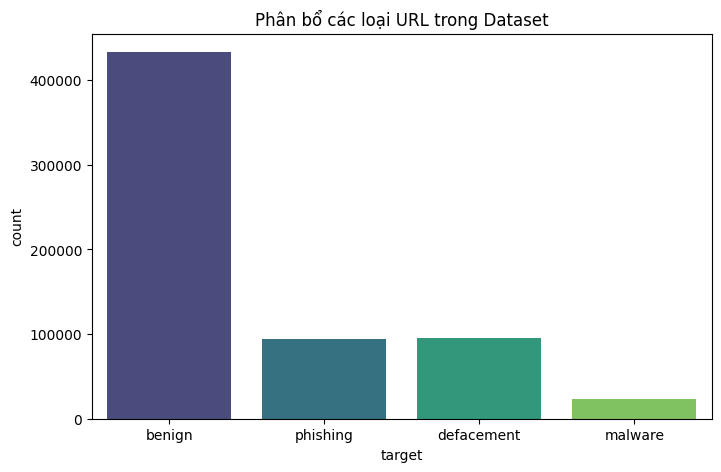

In [3]:
plt.figure(figsize=(8, 5))
sns.countplot(x=df['target'], palette='viridis')
plt.title('Phân bổ các loại URL trong Dataset')
plt.show()

In [4]:
x_train, x_test, y_train, y_test = train_test_split(
    X, Y, test_size=0.2, stratify=Y, random_state=42
)

print(f"Kích thước tập Train: {x_train.shape}")
print(f"Kích thước tập Test: {x_test.shape}")

Kích thước tập Train: (516893, 14)
Kích thước tập Test: (129224, 14)


In [5]:
print("🔥 Đang huấn luyện XGBoost Multi-class...")

model = xgb.XGBClassifier(
    n_estimators=500,        
    max_depth=10,             # Giữ độ sâu 10 để bắt pattern phức tạp
    learning_rate=0.1,
    subsample=0.9,            # Tăng subsample để học nhiều dữ liệu Benign nhất có thể
    colsample_bytree=0.8,     # Cho phép nhìn nhiều feature hơn
    objective='multi:softprob',
    random_state=42,
    tree_method='hist'
)

# Chạy fit 1 lần duy nhất
model.fit(x_train, y_train)

print("✅ Huấn luyện xong!")

🔥 Đang huấn luyện XGBoost Multi-class...
✅ Huấn luyện xong!


In [ ]:
from sklearn.metrics import classification_report, accuracy_score

# 1. Dự đoán trên tập test
y_pred = model.predict(x_test)

# 2. In báo cáo chi tiết
print("📊 BÁO CÁO KẾT QUẢ:")
print(f"🚀 ACCURACY XGBOOST: {accuracy_score(y_test, y_pred)*100:.2f}%")
print(classification_report(y_test, y_pred, target_names=le.classes_))

📊 BÁO CÁO KẾT QUẢ:
              precision    recall  f1-score   support

      benign       0.88      0.95      0.91     86616
  defacement       0.86      0.82      0.84     19062
     malware       0.98      0.90      0.94      4729
    phishing       0.74      0.53      0.62     18817

    accuracy                           0.86    129224
   macro avg       0.87      0.80      0.83    129224
weighted avg       0.86      0.86      0.86    129224



In [7]:
feature_names = X.columns.tolist()
joblib.dump(feature_names, "../models/feature_names.pkl")
joblib.dump(model, "../models/xgb_model.pkl")
joblib.dump(le, "../models/label_encoder.pkl")
print("💾 Đã lưu model và label encoder thành công!")

💾 Đã lưu model và label encoder thành công!


In [8]:
import pandas as pd
import numpy as np
import joblib
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, accuracy_score

# 1. NẠP DỮ LIỆU
print("📂 Đang nạp dữ liệu...")
df = pd.read_csv("../data/processed_malicious_url.csv")
df = df.drop_duplicates(subset=['url'])

X = df.drop(columns=['url', 'target'])
le = LabelEncoder()
y = le.fit_transform(df['target'])

# Chia 90/10 để tối đa data train cho Accuracy
x_train, x_test, y_train, y_test = train_test_split(
    X, y, test_size=0.1, stratify=y, random_state=42
)

# 2. CẤU HÌNH PHÁ TRẦN 80% (Sửa lỗi early_stopping_rounds)
print("🔥 Đang huấn luyện bản 'Accuracy Boost'...")
model = xgb.XGBClassifier(
    n_estimators=2000,
    max_depth=16,
    learning_rate=0.03,
    subsample=0.9,
    colsample_bytree=0.9,
    tree_method='hist',
    
    # ĐƯA EARLY STOPPING VÀO ĐÂY (Sửa lỗi TypeError)
    early_stopping_rounds=50,
    
    gamma=0.5,
    reg_lambda=5,
    objective='multi:softprob',
    n_jobs=-1,
    random_state=42
)

# 3. FIT MODEL (Bỏ early_stopping_rounds ở đây)
model.fit(
    x_train, y_train, 
    eval_set=[(x_test, y_test)], 
    verbose=100
)

# 4. KẾT QUẢ
y_pred = model.predict(x_test)
acc = accuracy_score(y_test, y_pred)
print(f"\n🚀 ACCURACY CUỐI CÙNG: {acc*100:.2f}%")
print("\n📊 BÁO CÁO CHI TIẾT:")
print(classification_report(y_test, y_pred, target_names=le.classes_))

# 5. LƯU MODEL
joblib.dump(X.columns.tolist(), "../models/feature_names.pkl")
joblib.dump(model, "../models/xgb_model.pkl")
joblib.dump(le, "../models/label_encoder.pkl")
print("✅ ĐÃ LƯU MODEL THÀNH CÔNG!")

📂 Đang nạp dữ liệu...
🔥 Đang huấn luyện bản 'Accuracy Boost'...
[0]	validation_0-mlogloss:1.14669
[100]	validation_0-mlogloss:0.41659
[200]	validation_0-mlogloss:0.35796
[300]	validation_0-mlogloss:0.34649
[400]	validation_0-mlogloss:0.34328
[500]	validation_0-mlogloss:0.34181
[600]	validation_0-mlogloss:0.34100
[700]	validation_0-mlogloss:0.34049
[800]	validation_0-mlogloss:0.34020
[900]	validation_0-mlogloss:0.33987
[1000]	validation_0-mlogloss:0.33964
[1100]	validation_0-mlogloss:0.33948
[1200]	validation_0-mlogloss:0.33934
[1300]	validation_0-mlogloss:0.33923
[1400]	validation_0-mlogloss:0.33915
[1500]	validation_0-mlogloss:0.33903
[1600]	validation_0-mlogloss:0.33894
[1700]	validation_0-mlogloss:0.33885
[1800]	validation_0-mlogloss:0.33876
[1900]	validation_0-mlogloss:0.33865
[1999]	validation_0-mlogloss:0.33858

🚀 ACCURACY CUỐI CÙNG: 86.59%

📊 BÁO CÁO CHI TIẾT:
              precision    recall  f1-score   support

      benign       0.88      0.94      0.91     43308
  defacemen

In [9]:
import pandas as pd
import numpy as np
import joblib
import lightgbm as lgb
from sklearn.cluster import KMeans
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import classification_report, accuracy_score, silhouette_score

# 1. NẠP DỮ LIỆU
print("📂 Đang nạp dữ liệu cho 2 phương pháp...")
df = pd.read_csv("../data/processed_malicious_url.csv").drop_duplicates(subset=['url'])
X = df.drop(columns=['url', 'target'])
le = LabelEncoder()
y = le.fit_transform(df['target'])

# Chuẩn hóa dữ liệu (Rất quan trọng cho Clustering)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# --- PHƯƠNG PHÁP 1: CLUSTERING (K-Means) ---
print("\n🔍 Đang thực hiện Clustering (K-Means) để tìm cấu trúc ẩn...")
# Giả sử ta muốn tìm 4 cụm tương ứng với 4 loại URL
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_scaled)
df['cluster'] = clusters
print("✅ Đã phân cụm xong. Check thử sự phân bổ nhãn trong từng cụm:")
print(pd.crosstab(df['target'], df['cluster']))

# --- PHƯƠNG PHÁP 2: CLASSIFICATION (LightGBM) ---
print("\n🚀 Đang huấn luyện LightGBM (Phát cuối cho Accuracy)...")
x_train, x_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.15, stratify=y, random_state=42)

lgbm = lgb.LGBMClassifier(
    n_estimators=1500,
    learning_rate=0.05,
    num_leaves=128,          # Tăng leaf để bắt pattern sâu hơn XGBoost
    tree_method='hist',
    n_jobs=-1,
    random_state=42
)

lgbm.fit(x_train, y_train, eval_set=[(x_test, y_test)], 
         callbacks=[lgb.early_stopping(stopping_rounds=50), lgb.log_evaluation(100)])

y_pred = lgbm.predict(x_test)
print(f"\n🎯 Accuracy LightGBM: {accuracy_score(y_test, y_pred)*100:.2f}%")
print(classification_report(y_test, y_pred, target_names=le.classes_))

# 3. LƯU KẾT QUẢ
joblib.dump(lgbm, "../models/lgbm_model_hd.pkl")
joblib.dump(kmeans, "../models/kmeans_model.pkl")
print("\n💾 Đã lưu cả 2 Model (Classification & Clustering).")

📂 Đang nạp dữ liệu cho 2 phương pháp...

🔍 Đang thực hiện Clustering (K-Means) để tìm cấu trúc ẩn...
✅ Đã phân cụm xong. Check thử sự phân bổ nhãn trong từng cụm:
cluster          0     1       2      3
target                                 
benign      154160  6624  272254     42
defacement   67139     0   28169      0
malware       7235    38    4602  11770
phishing     21449  1820   70482    333

🚀 Đang huấn luyện LightGBM (Phát cuối cho Accuracy)...
[LightGBM] [Warning] Unknown parameter: tree_method
[LightGBM] [Warning] Unknown parameter: tree_method
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.018037 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1304
[LightGBM] [Info] Number of data points in the train set: 549199, number of used features: 14
[LightGBM] [Warning] Unknown parameter: tree_method
[LightGBM] [Info] Start trainin

c:\Users\vppho\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Warning] Unknown parameter: tree_method

🎯 Accuracy LightGBM: 86.60%
              precision    recall  f1-score   support

      benign       0.88      0.95      0.91     64962
  defacement       0.86      0.83      0.85     14296
     malware       0.98      0.91      0.94      3547
    phishing       0.75      0.52      0.62     14113

    accuracy                           0.87     96918
   macro avg       0.87      0.80      0.83     96918
weighted avg       0.86      0.87      0.86     96918


💾 Đã lưu cả 2 Model (Classification & Clustering).
